### Graph Neural Networks & Blood Brain Barrier Permeability

In [9]:
import pandas as pd
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix

import sys, os
sys.path.append(os.path.abspath("../"))
from src.featurization import df_to_pyg_lists
from src.gnn_model import BBBP_GCN

In [2]:
# load dataset

df = pd.read_csv(r"../data/processed/neuro_natural_dataset.csv")

In [3]:
train_graphs, test_graphs = df_to_pyg_lists(df)

[22:35:24] WARNING: not removing hydrogen atom without neighbors
[22:35:24] WARNING: not removing hydrogen atom without neighbors
[22:35:24] WARNING: not removing hydrogen atom without neighbors
[22:35:24] WARNING: not removing hydrogen atom without neighbors
[22:35:24] WARNING: not removing hydrogen atom without neighbors
[22:35:24] WARNING: not removing hydrogen atom without neighbors
[22:35:24] WARNING: not removing hydrogen atom without neighbors
[22:35:24] WARNING: not removing hydrogen atom without neighbors
[22:35:25] WARNING: not removing hydrogen atom without neighbors
[22:35:25] WARNING: not removing hydrogen atom without neighbors
[22:35:25] WARNING: not removing hydrogen atom without neighbors
[22:35:25] WARNING: not removing hydrogen atom without neighbors
[22:35:25] WARNING: not removing hydrogen atom without neighbors
[22:35:25] WARNING: not removing hydrogen atom without neighbors
[22:35:25] WARNING: not removing hydrogen atom without neighbors
[22:35:25] WARNING: not r

In [4]:
len(train_graphs), len(test_graphs)

(1304, 327)

In [6]:
# data loaders
batch_size = 64
train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

In [7]:
# model, optimizer, loss (with class-imbalance weighting)

# pick device: MPS on Apple Silicon if available, else CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device:", device)
else:
    device = torch.device("cpu")
    print("Using device:", device)

in_channels = train_graphs[0].x.size(1)
model = BBBP_GCN(in_channels=in_channels, hidden_dim=64).to(device)

# class weights to handle imbalance (0 = non-perm, 1 = perm)
class_counts = df["permeable"].value_counts()
total = class_counts.sum()
w0 = total / (2 * class_counts[0.0])
w1 = total / (2 * class_counts[1.0])
class_weights = torch.tensor([w0, w1], dtype=torch.float).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

Using device: mps


In [8]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_model(model, loader, device):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = (probs >= 0.5).long()

        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_labels.append(batch.y.cpu())

    all_probs = torch.cat(all_probs).numpy()
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return {
        "auc": roc_auc_score(all_labels, all_probs),
        "f1": f1_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds),
        "recall": recall_score(all_labels, all_preds),
        "accuracy": accuracy_score(all_labels, all_preds),
    }

num_epochs = 40
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    if epoch % 5 == 0 or epoch == 1:
        metrics = eval_model(model, test_loader, device)
        print(
            f"Epoch {epoch:02d} | loss={train_loss:.4f} | "
            f"AUC={metrics['auc']:.3f} | F1={metrics['f1']:.3f} | "
            f"P={metrics['precision']:.3f} | R={metrics['recall']:.3f}"
        )

Epoch 01 | loss=0.6837 | AUC=0.757 | F1=0.910 | P=0.851 | R=0.978
Epoch 05 | loss=0.5673 | AUC=0.787 | F1=0.797 | P=0.922 | R=0.703
Epoch 10 | loss=0.5240 | AUC=0.797 | F1=0.846 | P=0.917 | R=0.784
Epoch 15 | loss=0.5015 | AUC=0.811 | F1=0.834 | P=0.931 | R=0.755
Epoch 20 | loss=0.4998 | AUC=0.819 | F1=0.791 | P=0.930 | R=0.688
Epoch 25 | loss=0.4723 | AUC=0.824 | F1=0.893 | P=0.935 | R=0.855
Epoch 30 | loss=0.4522 | AUC=0.830 | F1=0.887 | P=0.934 | R=0.844
Epoch 35 | loss=0.4554 | AUC=0.838 | F1=0.881 | P=0.930 | R=0.836
Epoch 40 | loss=0.4390 | AUC=0.846 | F1=0.857 | P=0.934 | R=0.792


### Misclassification Analysis

In [11]:
# collect predictions and indices from the GNN (test set)

@torch.no_grad()
def collect_gnn_predictions(model, loader, device):
    model.eval()
    all_probs = []
    all_preds = []
    all_labels = []
    all_idxs = []

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        probs = torch.softmax(logits, dim=1)[:, 1]  # P(permeable=1)
        preds = (probs >= 0.5).long()

        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_labels.append(batch.y.cpu())
        # idx was set on each Data in featurization.py. PyG batches these into batch.idx
        all_idxs.append(batch.idx.cpu())

    all_probs = torch.cat(all_probs).numpy()
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_idxs = torch.cat(all_idxs).numpy()

    return all_idxs, all_labels, all_preds, all_probs

idxs, y_true, y_pred, y_prob = collect_gnn_predictions(model, test_loader, device)

print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_true, y_pred))

Confusion matrix (rows=true, cols=pred):
[[ 43  15]
 [ 56 213]]


In [12]:
results = pd.DataFrame({
    "idx": idxs,
    "true": y_true,
    "pred": y_pred,
    "prob": y_prob,
})

results["correct"] = results["true"] == results["pred"]
results.head()

,idx,true,pred,prob,correct
0,4,1,1,0.937606,True
1,9,0,0,0.071478,True
2,17,0,0,0.232945,True
3,19,1,1,0.556024,True
4,20,0,0,0.152927,True


In [13]:
false_pos = results[(results["true"] == 0) & (results["pred"] == 1)]
false_neg = results[(results["true"] == 1) & (results["pred"] == 0)]

print("False positives:", len(false_pos))
print("False negatives:", len(false_neg))

False positives: 15
False negatives: 56


In [14]:
# map misclassified molecules back to the original DF

# sort by confidence (probability) within misclassified sets
false_pos_sorted = false_pos.sort_values("prob", ascending=False)    # confident but wrong 1's
false_neg_sorted = false_neg.sort_values("prob", ascending=True)     # confident it's 0 but true is 1

# take top 12 of each
fp_top = false_pos_sorted.head(12)
fn_top = false_neg_sorted.head(12)

fp_df = df.loc[fp_top["idx"]]
fn_df = df.loc[fn_top["idx"]]

fp_df[["smiles", "permeable", "mol_wt", "logp", "tpsa", "qed"]].head()

,smiles,permeable,mol_wt,logp,tpsa,qed
364,C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(C)[...,0.0,302.458,4.2693,37.30,0.725331
370,C[C@]12CC[C@H]3[C@@H](CCC4=CC(=O)CC[C@]34C)[C@...,0.0,288.431,3.8792,37.30,0.734230
1163,CC(C)(C)c1ccc(cc1)C(=O)CCCN2CCC(CC2)OC(c3ccccc...,0.0,469.669,7.2176,29.54,0.309941
368,C[C@]12CC[C@H]3[C@@H](CCC4=CC(=O)CC[C@H]34)[C@...,0.0,298.426,3.4925,37.30,0.695089
951,C[C@]12CC[C@H]3[C@@H](CCc4cc(O)ccc34)[C@@H]1CC...,0.0,272.388,3.6092,40.46,0.757170


#### False Positives Visualized

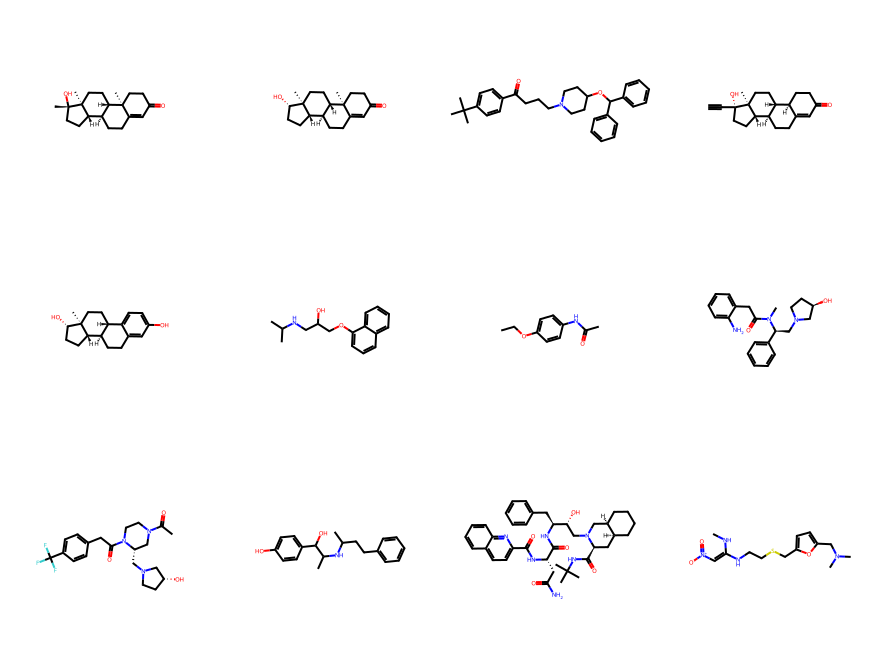

In [15]:
from rdkit import Chem
from rdkit.Chem import Draw

# False positives: predicted permeable (1) but actually non-permeable (0)
fp_mols = [Chem.MolFromSmiles(s) for s in fp_df["smiles"]]
fp_grid = Draw.MolsToGridImage(fp_mols, molsPerRow=4, subImgSize=(220, 220))
fp_grid

#### False Negatives Visualized

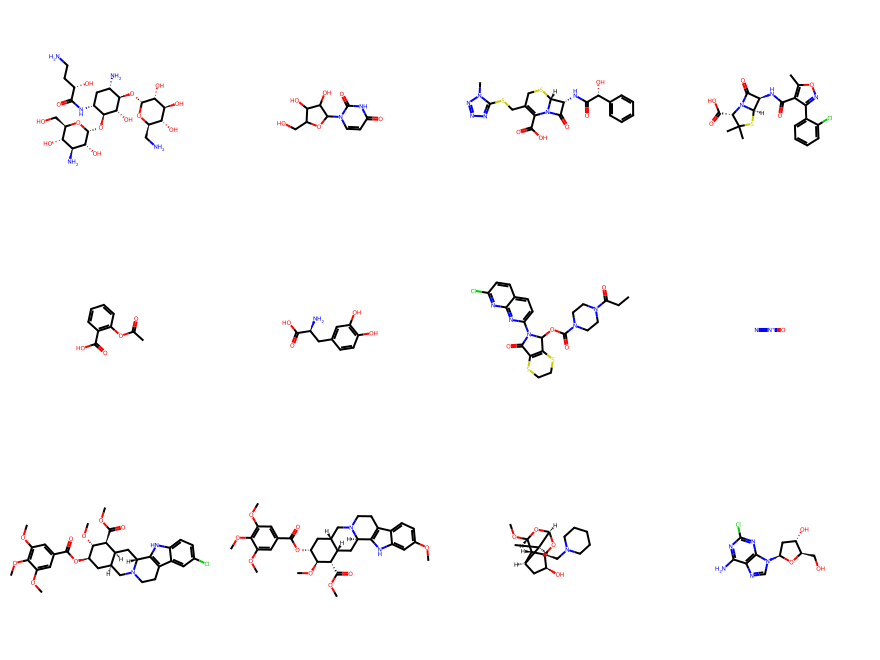

In [16]:
# False negatives: predicted non-permeable (0) but actually permeable (1)
fn_mols = [Chem.MolFromSmiles(s) for s in fn_df["smiles"]]
fn_grid = Draw.MolsToGridImage(fn_mols, molsPerRow=4, subImgSize=(220, 220))
fn_grid

In [17]:
# compare numeric insight on misclassified molecules

# attach model outputs to df for convenience
df_results = df.copy()
df_results.loc[results["idx"], "gnn_true"] = results["true"]
df_results.loc[results["idx"], "gnn_pred"] = results["pred"]
df_results.loc[results["idx"], "gnn_prob"] = results["prob"]

fp_full = df_results.loc[fp_top["idx"]]
fn_full = df_results.loc[fn_top["idx"]]

print("False positives descriptor means:")
print(fp_full[["mol_wt", "logp", "tpsa", "qed"]].mean(), "\n")

print("False negatives descriptor means:")
print(fn_full[["mol_wt", "logp", "tpsa", "qed"]].mean(), "\n")

print("Overall test-set descriptor means:")
test_rows = results["idx"]  # those indices were test set
print(df_results.loc[test_rows, ["mol_wt", "logp", "tpsa", "qed"]].mean())

False positives descriptor means:
mol_wt    343.460500
logp        3.209733
tpsa       58.202500
qed         0.644672
dtype: float64 

False negatives descriptor means:
mol_wt    372.874333
logp        0.456835
tpsa      119.465833
qed         0.482582
dtype: float64 

Overall test-set descriptor means:
mol_wt    327.567245
logp        2.429357
tpsa       65.001498
qed         0.651565
dtype: float64
